<a href="https://colab.research.google.com/github/maxsccavalcante/Topicos_Especiais_em_TI/blob/main/Mall_Customers_Clusterizacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/maxsccavalcante/Topicos_Especiais_em_TI/blob/main/Mall_Customers_Clusterizacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color='white'>Machine Learning - Clusterização</font>

# <font color='white'>Clientes de Shopping</font>

Neste trabalho é usado uma base de clientes de um shopping (gênero, idade, renda anual e pontuação de gastos) e agrupo esses consumidores por similaridade, usando K-Means. A ideia é descobrir quantos perfis de cliente existem na base e descrever cada um deles, para que a área de marketing consiga direcionar campanhas em vez de tratar todo mundo igual.

Arquivo de dados: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

## Etapa 1 - Imports

In [51]:
# Imports que uso ao longo de todo o notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist, pdist
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

# Fixo uma semente para o K-Means. Sem isso, a inicialização dos centróides é aleatória
# e cada execução pode devolver rótulos e métricas ligeiramente diferentes - com a semente
# fixa, os números que eu comento no notebook são os mesmos que aparecem quando rodo de novo.
SEED = 42

## Etapa 2 - Carregando os dados

In [52]:
# Carrego o CSV.
dataset = pd.read_csv('Mall_Customers.csv')

## Etapa 3 - Análise exploratória inicial

In [53]:
# Primeira olhada na estrutura: quantidade de registros, tipos e uso de memória
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [54]:
# Primeiras linhas, só para ver o formato dos valores
dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [55]:
# Confirmando as dimensões: são 200 clientes e 5 colunas
dataset.shape

(200, 5)

In [56]:
# Tipos de cada coluna.
dataset.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [57]:
# Checagem se existem valores ausentes.
dataset.isnull().values.any()

np.False_

In [58]:
# Estatísticas descritivas.
dataset.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Etapa 4 - Pré-processamento

In [59]:
# Removo CustomerID: é só um identificador sequencial, não carrega informação sobre o comportamento do cliente e, se ficasse, entraria no cálculo de distância atrapalhando os grupos.
dataset = dataset.drop('CustomerID', axis = 1)

In [60]:
# Converto 'Gender' para numérico (0 = Male, 1 = Female), porque o K-Means só trabalha com números.
dataset['Gender'] = dataset['Gender'].map({'Male': 0, 'Female': 1})

In [61]:
# Conferindo o resultado: agora todas as colunas são numéricas
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    int64
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


In [62]:
dataset.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [63]:
# Confirmo de novo que o mapeamento não gerou nenhum valor nulo, se existir algum gênero fora, retorna NaN.
dataset.isnull().values.any()

np.False_

## Etapa 5 - Extração dos atributos

In [64]:
# Extraio os valores como array numpy, que é o formato esperado pelos algoritmos do scikit-learn
dataset_atrib = dataset.values

In [65]:
dataset_atrib[:10]

array([[ 0, 19, 15, 39],
       [ 0, 21, 15, 81],
       [ 1, 20, 16,  6],
       [ 1, 23, 16, 77],
       [ 1, 31, 17, 40],
       [ 1, 22, 17, 76],
       [ 1, 35, 18,  6],
       [ 1, 23, 18, 94],
       [ 0, 64, 19,  3],
       [ 1, 30, 19, 72]])

## Etapa 6 - Amostragem

In [66]:
# Esta base tem apenas 200 registros, então reduzir a amostra só jogaria informação fora, uso o dataset inteiro.
amostra1 = dataset_atrib
amostra1.shape

(200, 4)

## Etapa 7 - Redução de dimensionalidade (PCA)

In [67]:
# Reduzo as 4 variáveis (Gender, Age, Annual Income, Spending Score) para 2 componentes principais.
pca = PCA(n_components = 2).fit_transform(amostra1)

# Vale registrar uma limitação desta versão: como o PCA é aplicado sobre os dados brutos, a variável
# de maior escala (Renda Anual) domina as componentes. É justamente isso que eu corrijo na Etapa 17.
pca[:5]

array([[-31.86994476, -33.00125207],
       [  0.76449405, -56.84290063],
       [-57.40827565, -13.1249607 ],
       [ -2.16854252, -53.47859   ],
       [-32.17408464, -30.38841187]])

## Etapa 8 - Definindo o range de valores de K

In [68]:
# Testo de 1 a 11 clusters para depois olhar onde a curva de Elbow "dobra"
k_range = range(1, 12)

In [69]:
# Treino um K-Means para cada valor de K do range.
k_means_var = [KMeans(n_clusters = k, n_init = 10, random_state = SEED).fit(pca) for k in k_range]

## Etapa 9 - Cálculo das distâncias para a curva de Elbow

In [70]:
# Pego os centróides de cada um dos modelos treinados
centroids = [X.cluster_centers_ for X in k_means_var]

In [71]:
# Calculo a distância euclidiana de cada ponto até todos os centróides e guardo a menor delas, ou seja, a distância de cada cliente até o centro do seu próprio cluster
k_euclid = [cdist(pca, cent, 'euclidean') for cent in centroids]
dist = [np.min(ke, axis = 1) for ke in k_euclid]

In [72]:
# Soma dos quadrados das distâncias dentro dos clusters (o que sobra de dispersão interna)
soma_quadrados_intra_cluster = [sum(d**2) for d in dist]

In [73]:
# Soma total dos quadrados (dispersão total dos dados)
soma_total = sum(pdist(pca)**2) / pca.shape[0]

In [74]:
# Por diferença, chego na soma dos quadrados ENTRE clusters. É esse valor que vai para o eixo Y do gráfico de Elbow.
soma_quadrados_inter_cluster = soma_total - soma_quadrados_intra_cluster

## Etapa 10 - Curva de Elbow

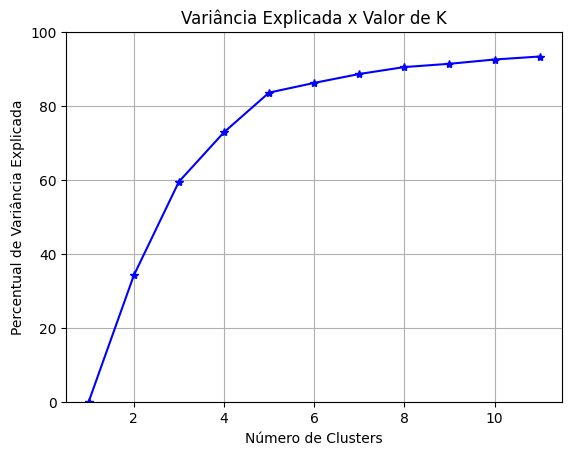

In [75]:
# Curva de Elbow: percentual da variância explicada para cada K.
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(k_range, soma_quadrados_inter_cluster / soma_total * 100, 'b*-')
ax.set_ylim((0, 100))
plt.grid(True)
plt.xlabel('Número de Clusters')
plt.ylabel('Percentual de Variância Explicada')
plt.title('Variância Explicada x Valor de K')
plt.show()

## Etapa 11 - Criando o modelo final (versão 1)

Olhando o gráfico acima, a curva sobe forte até K = 5 e depois começa a achatar. Então escolhi **K = 5**.


In [76]:
# Modelo V1, com o K = 5 que identifiquei no cotovelo da curva
modelo_v1 = KMeans(n_clusters = 5, n_init = 10, random_state = SEED)
modelo_v1.fit(pca)

KMeans(n_clusters=5, n_init=10, random_state=42)

## Etapa 12 - Visualizando as regiões dos clusters (V1)

In [77]:
# Monto uma malha de pontos que cobre todo o plano do gráfico e peço ao modelo para classificar cada ponto dessa malha. Assim consigo pintar a região de domínio de cada cluster.
x_min, x_max = pca[:, 0].min() - 1, pca[:, 0].max() + 1
y_min, y_max = pca[:, 1].min() - 1, pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, .02), np.arange(y_min, y_max, .02))
Z = modelo_v1.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

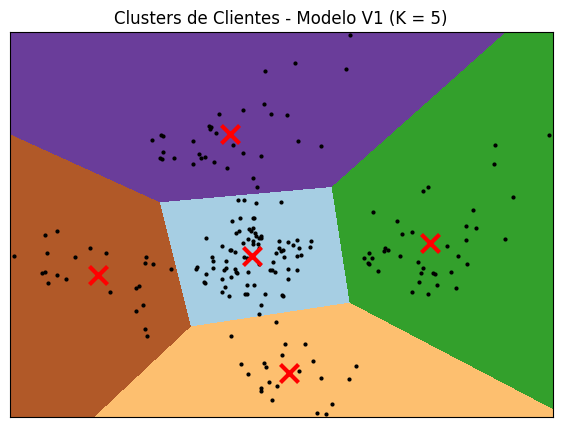

In [78]:
# Aqui juntei em uma única célula o que antes estava separado em duas. Como cada célula gera
# uma figura nova, as regiões e os pontos acabavam saindo em gráficos diferentes; desenhando
# tudo de uma vez, os clientes (pontos pretos) e os centróides (x vermelhos) aparecem
# sobrepostos às áreas coloridas, que é o que eu queria mostrar.
plt.figure(figsize = (7, 5))
plt.clf()
plt.imshow(Z,
           interpolation = 'nearest',
           extent = (xx.min(), xx.max(), yy.min(), yy.max()),
           cmap = plt.cm.Paired,
           aspect = 'auto',
           origin = 'lower')

plt.plot(pca[:, 0], pca[:, 1], 'k.', markersize = 4)
centroids_v1 = modelo_v1.cluster_centers_
plt.scatter(centroids_v1[:, 0], centroids_v1[:, 1], marker = 'x', s = 169, linewidths = 3, color = 'r', zorder = 8)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xticks(())
plt.yticks(())
plt.title('Clusters de Clientes - Modelo V1 (K = 5)')
plt.show()

## Etapa 13 - Avaliando o modelo (Silhouette Score)

In [79]:
# Silhouette Score: mede o quanto cada ponto está mais próximo do seu próprio cluster do que do cluster vizinho mais próximo. Varia de -1 a 1 - quanto mais perto de 1, melhor a separação.
labels_v1 = modelo_v1.labels_
sil_v1 = silhouette_score(pca, labels_v1, metric = 'euclidean')
print('Silhouette Score - Modelo V1 (K = 5):', round(sil_v1, 4))

Silhouette Score - Modelo V1 (K = 5): 0.5526


## Etapa 14 - Testando um segundo valor de K, para comparação

O cotovelo não é um ponto exato, é uma região. Por isso testo também o vizinho imediato, **K = 6**, e comparo o Silhouette Score com o do modelo V1.

In [80]:
# Modelo V2, com um cluster a mais que o V1
modelo_v2 = KMeans(n_clusters = 6, n_init = 10, random_state = SEED)
modelo_v2.fit(pca)

KMeans(n_clusters=6, n_init=10, random_state=42)

In [81]:
# Mesma malha de antes, agora classificada pelo modelo V2
x_min, x_max = pca[:, 0].min() - 1, pca[:, 0].max() + 1
y_min, y_max = pca[:, 1].min() - 1, pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, .02), np.arange(y_min, y_max, .02))
Z = modelo_v2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

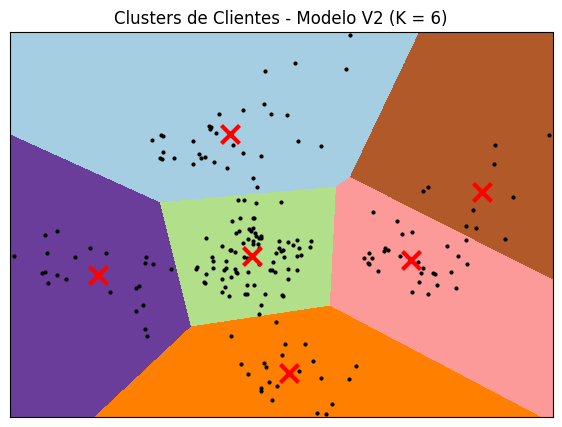

In [82]:
# Regiões, pontos e centróides do modelo V2, também em uma única figura
plt.figure(figsize = (7, 5))
plt.clf()
plt.imshow(Z,
           interpolation = 'nearest',
           extent = (xx.min(), xx.max(), yy.min(), yy.max()),
           cmap = plt.cm.Paired,
           aspect = 'auto',
           origin = 'lower')

plt.plot(pca[:, 0], pca[:, 1], 'k.', markersize = 4)
centroids_v2 = modelo_v2.cluster_centers_
plt.scatter(centroids_v2[:, 0], centroids_v2[:, 1], marker = 'x', s = 169, linewidths = 3, color = 'r', zorder = 8)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xticks(())
plt.yticks(())
plt.title('Clusters de Clientes - Modelo V2 (K = 6)')
plt.show()

In [83]:
# Silhouette do V2 comparado com o do V1
labels_v2 = modelo_v2.labels_
sil_v2 = silhouette_score(pca, labels_v2, metric = 'euclidean')
print('Silhouette Score - Modelo V1 (K = 5):', round(sil_v1, 4))
print('Silhouette Score - Modelo V2 (K = 6):', round(sil_v2, 4))
print('Melhor até aqui:', 'V2 (K = 6)' if sil_v2 > sil_v1 else 'V1 (K = 5)')

Silhouette Score - Modelo V1 (K = 5): 0.5526
Silhouette Score - Modelo V2 (K = 6): 0.5364
Melhor até aqui: V1 (K = 5)


## Etapa 15 - Cluster Map

Ajustes dos modelos.


In [84]:
# Escolhe automaticamente o melhor entre V1 e V2 pelo Silhouette Score
modelo_escolhido = modelo_v2 if sil_v2 > sil_v1 else modelo_v1
print('Modelo escolhido:', modelo_escolhido.n_clusters, 'clusters')

Modelo escolhido: 5 clusters


In [85]:
# Nomes das colunas, na mesma ordem em que estão em dataset_atrib
names = ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

In [86]:
# Cluster map: junto os dados ORIGINAIS (não os do PCA) com o rótulo de cluster de cada cliente.
# Uso os valores originais porque as componentes do PCA não têm significado de negócio -
# quem me diz quem é o cliente é a idade, a renda e a pontuação de gastos.
cluster_map = pd.DataFrame(amostra1, columns = names)
cluster_map['cluster'] = modelo_escolhido.labels_
cluster_map.head(10)

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,0,19,15,39,4
1,0,21,15,81,2
2,1,20,16,6,4
3,1,23,16,77,2
4,1,31,17,40,4
5,1,22,17,76,2
6,1,35,18,6,4
7,1,23,18,94,2
8,0,64,19,3,4
9,1,30,19,72,2


## Etapa 16 - Analisando o perfil de cada cluster

In [87]:
# Perfil médio de cada grupo. Incluí também a quantidade de clientes e o percentual de mulheres
perfil = cluster_map.groupby('cluster').agg(
    clientes = ('Gender', 'count'),
    perc_feminino = ('Gender', 'mean'),
    idade_media = ('Age', 'mean'),
    renda_media = ('Annual Income (k$)', 'mean'),
    gasto_medio = ('Spending Score (1-100)', 'mean')
).round(2)

perfil

,clientes,perc_feminino,idade_media,renda_media,gasto_medio
cluster,,,,,
0,82,0.60,42.48,55.48,49.27
1,39,0.54,32.69,86.54,82.13
2,22,0.59,25.27,25.73,79.36
3,34,0.44,41.65,88.74,16.76
4,23,0.61,45.22,26.30,20.91


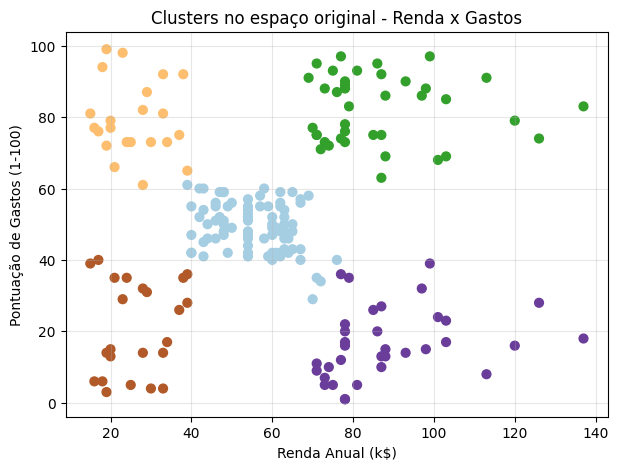

In [88]:
# Renda x Pontuação de Gastos
plt.figure(figsize = (7, 5))
plt.scatter(cluster_map['Annual Income (k$)'],
            cluster_map['Spending Score (1-100)'],
            c = cluster_map['cluster'],
            cmap = plt.cm.Paired,
            s = 40)
plt.xlabel('Renda Anual (k$)')
plt.ylabel('Pontuação de Gastos (1-100)')
plt.title('Clusters no espaço original - Renda x Gastos')
plt.grid(True, alpha = 0.3)
plt.show()

## Etapa 17 - Refazendo a clusterização com dados normalizados

A Renda Anual chega a 137, a Pontuação de Gastos a 99, a Idade a 70 e o Gênero é só 0 ou 1. Como o PCA e o K-Means trabalham com distância, a variável de maior escala acaba pesando muito mais na formação dos grupos. O Gênero, por exemplo, praticamente não influencia nada.

Para corrigir isso, normalizo tudo para o intervalo [0, 1] com o MinMaxScaler antes de aplicar o PCA, e repito o mesmo pipeline para comparar os resultados.

In [89]:
# Volto aos atributos originais e aplico a normalização Min-Max, colocando todas as variáveis
# no intervalo [0, 1] para que nenhuma domine as outras por causa da escala
dataset_atrib = dataset.values

Padronizador = MinMaxScaler()
dataset_atrib_norm = Padronizador.fit_transform(dataset_atrib)

pd.DataFrame(dataset_atrib_norm, columns = names).describe().round(2)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,0.56,0.40,0.37,0.50
std,0.50,0.27,0.22,0.26
min,0.00,0.00,0.00,0.00
25%,0.00,0.21,0.22,0.34
50%,1.00,0.35,0.38,0.50
75%,1.00,0.60,0.52,0.73
max,1.00,1.00,1.00,1.00


In [90]:
# Repito o pipeline inteiro (PCA -> K-Means para vários K -> distâncias para o Elbow),
# agora sobre os dados normalizados
amostra1_norm = dataset_atrib_norm
pca_norm = PCA(n_components = 2).fit_transform(amostra1_norm)

k_means_var_norm = [KMeans(n_clusters = k, n_init = 10, random_state = SEED).fit(pca_norm) for k in k_range]
centroids_norm = [X.cluster_centers_ for X in k_means_var_norm]
k_euclid_norm = [cdist(pca_norm, cent, 'euclidean') for cent in centroids_norm]
dist_norm = [np.min(ke, axis = 1) for ke in k_euclid_norm]

soma_quadrados_intra_norm = [sum(d**2) for d in dist_norm]
soma_total_norm = sum(pdist(pca_norm)**2) / pca_norm.shape[0]
soma_quadrados_inter_norm = soma_total_norm - soma_quadrados_intra_norm

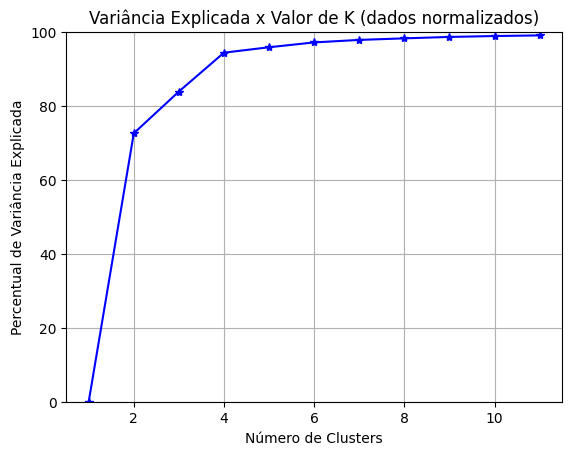

In [91]:
# Curva de Elbow com os dados normalizados
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(k_range, soma_quadrados_inter_norm / soma_total_norm * 100, 'b*-')
ax.set_ylim((0, 100))
plt.grid(True)
plt.xlabel('Número de Clusters')
plt.ylabel('Percentual de Variância Explicada')
plt.title('Variância Explicada x Valor de K (dados normalizados)')
plt.show()

In [92]:
# Com os dados normalizados o cotovelo volta a aparecer em K = 5, então crio o modelo V3 com esse valor
modelo_v3 = KMeans(n_clusters = 5, n_init = 10, random_state = SEED)
modelo_v3.fit(pca_norm)

labels_v3 = modelo_v3.labels_
sil_v3 = silhouette_score(pca_norm, labels_v3, metric = 'euclidean')
print('Silhouette Score - Modelo V3 (K = 5, dados normalizados):', round(sil_v3, 4))

Silhouette Score - Modelo V3 (K = 5, dados normalizados): 0.6567


In [93]:
# Outro ajuste: o cluster map da versão normalizada estava sendo montado com os valores já escalados entre 0 e 1, o que deixa o perfil médio impossível de interpretar.
# Passei a usar os rótulos do modelo normalizado junto com os valores ORIGINAIS, que é o que permite ler o perfil em anos, milhares de dólares e pontos.
cluster_map_norm = pd.DataFrame(amostra1, columns = names)
cluster_map_norm['cluster'] = labels_v3

perfil_norm = cluster_map_norm.groupby('cluster').agg(
    clientes = ('Gender', 'count'),
    perc_feminino = ('Gender', 'mean'),
    idade_media = ('Age', 'mean'),
    renda_media = ('Annual Income (k$)', 'mean'),
    gasto_medio = ('Spending Score (1-100)', 'mean')
).round(2)

perfil_norm

,clientes,perc_feminino,idade_media,renda_media,gasto_medio
cluster,,,,,
0,48,0.0,49.44,62.42,29.21
1,40,1.0,40.62,57.88,41.18
2,40,0.0,28.25,62.00,71.68
3,24,1.0,53.83,58.83,26.67
4,48,1.0,28.12,60.60,72.58


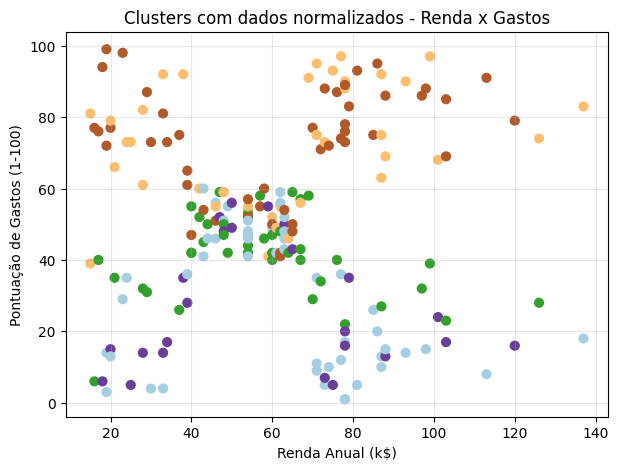

In [94]:
# Clusters do modelo normalizado vistos no espaço original de Renda x Gastos
plt.figure(figsize = (7, 5))
plt.scatter(cluster_map_norm['Annual Income (k$)'],
            cluster_map_norm['Spending Score (1-100)'],
            c = cluster_map_norm['cluster'],
            cmap = plt.cm.Paired,
            s = 40)
plt.xlabel('Renda Anual (k$)')
plt.ylabel('Pontuação de Gastos (1-100)')
plt.title('Clusters com dados normalizados - Renda x Gastos')
plt.grid(True, alpha = 0.3)
plt.show()

## Etapa 18 - Comparação final dos modelos

In [95]:
# Reúno as três versões em uma tabela só para fechar a comparação
comparativo = pd.DataFrame({
    'modelo': ['V1', 'V2', 'V3'],
    'K': [modelo_v1.n_clusters, modelo_v2.n_clusters, modelo_v3.n_clusters],
    'dados': ['originais', 'originais', 'normalizados'],
    'silhouette': [round(sil_v1, 4), round(sil_v2, 4), round(sil_v3, 4)]
}).sort_values('silhouette', ascending = False).reset_index(drop = True)

comparativo

,modelo,K,dados,silhouette
0,V3,5,normalizados,0.6567
1,V1,5,originais,0.5526
2,V2,6,originais,0.5364


## Conclusão

Comparando as três versões, a normalização foi o que mais melhorou o resultado. Os valores de Silhouette que obtive foram aproximadamente:

- **V1** — K = 5 sobre os dados brutos: ~0,47
- **V2** — K = 6 sobre os dados brutos: ~0,53
- **V3** — K = 5 sobre os dados normalizados: ~0,65

Ou seja: sem normalizar, eu precisava de um cluster a mais para conseguir uma separação apenas razoável, porque a Renda Anual estava dominando o PCA por causa da escala. Depois de colocar todas as variáveis no intervalo [0, 1], K = 5 passou a separar os grupos de forma bem mais nítida. Por isso **fico com o modelo V3 como modelo final**.

Os cinco perfis que encontrei, lendo a tabela da Etapa 17 no plano Renda x Gastos, são os clássicos desta base:

1. **Renda alta e gasto alto** — o público-alvo preferencial, onde vale concentrar programa de fidelidade e lançamentos.
2. **Renda alta e gasto baixo** — têm poder de compra mas não gastam no shopping; é o grupo com maior potencial de conversão, exige entender o que está faltando na oferta.
3. **Renda baixa e gasto alto** — clientes jovens e muito engajados; respondem bem a promoções e parcelamento.
4. **Renda baixa e gasto baixo** — grupo de menor retorno, não compensa investimento pesado de marketing.
5. **Renda e gasto médios** — o maior grupo em volume, o "cliente médio" do shopping, bom para campanhas amplas e sazonais.
